In [1]:
import numpy as np
import pandas as pd

import librosa

from datasets import load_dataset, Audio

In [2]:
dataset = load_dataset(
    "urgent-challenge/urgent2025-sqa",
    split="blind_test_mos",
    streaming=True
)

dataset = dataset.cast_column(
    "audio",
    Audio(decode=True)
)

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

In [3]:
samples = []

for i, sample in enumerate(dataset):

    samples.append(sample)

    if i == 999:
        break

print("Number of samples:", len(samples))

Number of samples: 1000


In [4]:
print(samples[0].keys())

dict_keys(['audio', 'sample_id', 'system_id', 'mos', 'distill_mos', 'dnsmos_ovrl', 'estoi', 'lsd', 'mcd', 'pesq', 'pesqc2', 'sdr', 'nisqa_mos', 'lps', 'scoreq', 'sigmos_col', 'sigmos_disc', 'sigmos_loud', 'sigmos_noise', 'sigmos_ovrl', 'sigmos_reverb', 'sigmos_sig', 'spksim', 'sbert', 'utmos', 'raw_ratings'])


In [5]:
def extract_features(sample):
    audio = sample["audio"]

    waveform = audio.get_all_samples()

    samples = waveform.data.numpy()
    original_sample_rate = waveform.sample_rate

    y = samples.squeeze()

    # Standardize sampling rate
    TARGET_SR = 16000

    if original_sample_rate != TARGET_SR:
        y = librosa.resample(
            y,
            orig_sr=original_sample_rate,
            target_sr=TARGET_SR
        )

    sample_rate = TARGET_SR

    # Basic Information
    duration = len(y) / sample_rate

    # RMS Energy
    rms = librosa.feature.rms(y=y)
    rms_values = rms.flatten()

    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    zcr_values = zcr.flatten()

    # Spectral Centroid
    centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sample_rate
    )
    centroid_values = centroid.flatten()

    # Spectral Bandwidth
    bandwidth = librosa.feature.spectral_bandwidth(
        y=y,
        sr=sample_rate
    )
    bandwidth_values = bandwidth.flatten()

    # Spectral Rolloff
    rolloff = librosa.feature.spectral_rolloff(
        y=y,
        sr=sample_rate
    )
    rolloff_values = rolloff.flatten()

    # Spectral Contrast
    contrast = librosa.feature.spectral_contrast(
        y=y,
        sr=sample_rate,
        n_bands=5,
        fmin=200
    )

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sample_rate,
        n_mfcc=13
    )

    # Pitch
    f0, voiced_flag, voice_prob = librosa.pyin(
        y,
        fmin=librosa.note_to_hz("c2"),
        fmax=librosa.note_to_hz("c7"),
        sr=sample_rate
    )

    valid_pitch = f0[~np.isnan(f0)]

    # Feature Dictionary
    features = {
        # Basic
        "duration": duration,

        # RMS
        "rms_mean": np.mean(rms_values),
        "rms_std": np.std(rms_values),
        "rms_min": np.min(rms_values),
        "rms_max": np.max(rms_values),
        "rms_median": np.median(rms_values),

        # ZCR
        "zcr_mean": np.mean(zcr_values),
        "zcr_std": np.std(zcr_values),
        "zcr_min": np.min(zcr_values),
        "zcr_max": np.max(zcr_values),
        "zcr_median": np.median(zcr_values),

        # Spectral Centroid
        "spectral_centroid_mean": np.mean(centroid_values),
        "spectral_centroid_std": np.std(centroid_values),

        # Spectral Bandwidth
        "spectral_bandwidth_mean": np.mean(bandwidth_values),
        "spectral_bandwidth_std": np.std(bandwidth_values),

        # Spectral Rolloff
        "spectral_rolloff_mean": np.mean(rolloff_values),
        "spectral_rolloff_std": np.std(rolloff_values),

        # Spectral Contrast
        "spectral_contrast_mean": np.mean(contrast),
        "spectral_contrast_std": np.std(contrast),
    }

    # MFCC Statistics
    for i in range(mfcc.shape[0]):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    # Pitch Statistics
    if len(valid_pitch) > 0:

        features["pitch_mean"] = np.mean(valid_pitch)
        features["pitch_std"] = np.std(valid_pitch)
        features["pitch_min"] = np.min(valid_pitch)
        features["pitch_max"] = np.max(valid_pitch)
        features["pitch_median"] = np.median(valid_pitch)

    else:

        features["pitch_mean"] = np.nan
        features["pitch_std"] = np.nan
        features["pitch_min"] = np.nan
        features["pitch_max"] = np.nan
        features["pitch_median"] = np.nan

    # Metadata
    features["sample_id"] = sample["sample_id"]
    features["system_id"] = sample["system_id"]

    # Target
    features["mos"] = sample["mos"]

    return features

In [6]:
test_feature = extract_features(samples[0])
print('Number of extracted values:', len(test_feature))
test_feature

Number of extracted values: 53


{'duration': 6.149125,
 'rms_mean': np.float32(0.17385755),
 'rms_std': np.float32(0.054849688),
 'rms_min': np.float32(0.075962916),
 'rms_max': np.float32(0.3984962),
 'rms_median': np.float32(0.16407044),
 'zcr_mean': np.float64(0.22819432075777202),
 'zcr_std': np.float64(0.10471867699011841),
 'zcr_min': np.float64(0.044921875),
 'zcr_max': np.float64(0.49462890625),
 'zcr_median': np.float64(0.21923828125),
 'spectral_centroid_mean': np.float64(2296.3196596292946),
 'spectral_centroid_std': np.float64(514.4407182487477),
 'spectral_bandwidth_mean': np.float64(2474.5105126414105),
 'spectral_bandwidth_std': np.float64(200.19143203737585),
 'spectral_rolloff_mean': np.float64(5835.208873056995),
 'spectral_rolloff_std': np.float64(414.57440725171966),
 'spectral_contrast_mean': np.float64(22.808857432136488),
 'spectral_contrast_std': np.float64(14.552576257664388),
 'mfcc_1_mean': np.float32(-107.90926),
 'mfcc_1_std': np.float32(16.593193),
 'mfcc_2_mean': np.float32(107.07115),


In [7]:
feature_row = []

for i,sample in enumerate(samples):
    try:
        featrues = extract_features(sample)
        feature_row.append(featrues)
        if (i+1) % 50 == 0:
            print(f'Processed {i+1}/1000')

    except Exception as e:
        print(f'Error Processing sample {i}:{e}')

Processed 50/1000
Processed 100/1000
Processed 150/1000
Processed 200/1000
Processed 250/1000
Processed 300/1000
Processed 350/1000
Processed 400/1000
Processed 450/1000
Processed 500/1000
Processed 550/1000
Processed 600/1000
Processed 650/1000
Processed 700/1000
Processed 750/1000
Processed 800/1000
Processed 850/1000
Processed 900/1000
Processed 950/1000
Processed 1000/1000


In [8]:
feature_df = pd.DataFrame(
    feature_row
)
print('shape:',feature_df.shape)

shape: (1000, 53)


In [9]:
feature_df.head()

,duration,rms_mean,rms_std,rms_min,rms_max,rms_median,zcr_mean,zcr_std,zcr_min,zcr_max,...,mfcc_13_mean,mfcc_13_std,pitch_mean,pitch_std,pitch_min,pitch_max,pitch_median,sample_id,system_id,mos
0,6.149125,0.173858,0.054850,0.075963,0.398496,0.164070,0.228194,0.104719,0.044922,0.494629,...,-19.662941,7.825193,1094.502439,881.983948,192.630595,2033.420746,314.742105,urgent25_blind_test_fileid_000001,urgent25_blind_test_submission_716,1.500
1,5.666062,0.098440,0.050911,0.019863,0.202346,0.100245,0.184403,0.110771,0.041016,0.612305,...,-7.641559,6.461961,203.667094,54.936994,91.436169,320.243700,199.423698,urgent25_blind_test_fileid_000002,urgent25_blind_test_submission_716,2.125
2,3.627000,0.086625,0.047802,0.020838,0.204252,0.080475,0.130320,0.124145,0.011230,0.585938,...,-3.789234,6.191098,197.237511,56.709864,101.454781,290.291740,202.345478,urgent25_blind_test_fileid_000003,urgent25_blind_test_submission_716,3.750
3,3.460437,0.117501,0.082194,0.000371,0.296434,0.124968,0.053671,0.035271,0.008301,0.189453,...,-4.772955,8.028147,211.423097,46.373234,98.566561,316.565388,211.282048,urgent25_blind_test_fileid_000004,urgent25_blind_test_submission_716,1.625
4,3.664563,0.073171,0.043997,0.007853,0.181572,0.077773,0.105206,0.082447,0.039551,0.522949,...,-7.895499,6.907146,123.681352,28.796260,72.993346,189.321316,126.356819,urgent25_blind_test_fileid_000005,urgent25_blind_test_submission_716,3.625


In [11]:
feature_columns = [
    column
    for column in feature_df.columns
    if column not in [
        "sample_id",
        "system_id",
        "mos"
    ]
]

In [12]:
X = feature_df[
    feature_columns
]

In [13]:
y = feature_df["mos"]

In [14]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 50)
y shape: (1000,)


In [15]:
missing = X.isna().sum()

missing[
    missing > 0
]

pitch_mean      6
pitch_std       6
pitch_min       6
pitch_max       6
pitch_median    6
dtype: int64

In [16]:
missing_percentage = (
    X.isna().mean() * 100
).sort_values(
    ascending=False
)

missing_percentage[
    missing_percentage > 0
]

pitch_max       0.6
pitch_median    0.6
pitch_mean      0.6
pitch_min       0.6
pitch_std       0.6
dtype: float64

In [17]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy="median"
)

X_imputed = imputer.fit_transform(X)

print("Shape:", X_imputed.shape)

Shape: (1000, 50)


In [18]:
X = pd.DataFrame(
    X_imputed,
    columns=feature_columns
)

print(X.shape)

(1000, 50)


In [19]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,1000.0,6.450151,2.987198,3.000000,4.248703,5.691125,7.632828,19.880000
rms_mean,1000.0,0.094750,0.042289,0.008839,0.067453,0.091721,0.116969,0.372463
rms_std,1000.0,0.059312,0.026708,0.005232,0.042219,0.057043,0.072165,0.221027
rms_min,1000.0,0.012037,0.017651,0.000000,0.000060,0.004009,0.017996,0.109960
rms_max,1000.0,0.256492,0.095278,0.038722,0.198800,0.260423,0.309623,0.712582
rms_median,1000.0,0.086552,0.048666,0.000132,0.052462,0.081666,0.112687,0.461827
zcr_mean,1000.0,0.119354,0.059053,0.015959,0.075884,0.108001,0.148801,0.447043
zcr_std,1000.0,0.070871,0.040883,0.007541,0.037908,0.064886,0.097165,0.314464
zcr_min,1000.0,0.023808,0.022602,0.000000,0.006836,0.021484,0.033691,0.203125
zcr_max,1000.0,0.379894,0.186599,0.055176,0.223022,0.365479,0.517944,0.934082


In [20]:
y.describe()

count    1000.000000
mean        2.027375
std         0.739151
min         1.000000
25%         1.500000
50%         1.875000
75%         2.500000
max         4.625000
Name: mos, dtype: float64

In [22]:
correlation = (
    feature_df[
        feature_columns + ["mos"]
    ]
    .corr()["mos"]
    .drop("mos")
    .sort_values()
)

correlation

mfcc_1_mean               -0.494533
rms_min                   -0.333927
rms_median                -0.231296
rms_mean                  -0.224541
mfcc_12_mean              -0.220503
mfcc_2_mean               -0.178952
mfcc_10_mean              -0.163469
zcr_min                   -0.156752
mfcc_4_mean               -0.111948
zcr_median                -0.110683
mfcc_7_mean               -0.102176
mfcc_9_mean               -0.097403
pitch_min                 -0.091000
pitch_median              -0.082243
pitch_mean                -0.078794
spectral_contrast_std     -0.063269
mfcc_8_mean               -0.050022
mfcc_6_mean               -0.028912
pitch_max                 -0.023926
pitch_std                 -0.022797
mfcc_13_mean              -0.017911
zcr_mean                  -0.007768
spectral_rolloff_mean      0.002796
mfcc_11_mean               0.003367
duration                   0.023602
spectral_bandwidth_mean    0.032119
spectral_centroid_mean     0.033699
mfcc_5_mean                0

In [23]:
correlation.head(10)

mfcc_1_mean    -0.494533
rms_min        -0.333927
rms_median     -0.231296
rms_mean       -0.224541
mfcc_12_mean   -0.220503
mfcc_2_mean    -0.178952
mfcc_10_mean   -0.163469
zcr_min        -0.156752
mfcc_4_mean    -0.111948
zcr_median     -0.110683
Name: mos, dtype: float64

In [24]:
correlation.tail(10)

spectral_centroid_std     0.458153
mfcc_7_std                0.465596
mfcc_8_std                0.466116
spectral_bandwidth_std    0.471826
mfcc_6_std                0.473024
spectral_rolloff_std      0.475646
mfcc_5_std                0.505070
mfcc_2_std                0.517281
mfcc_4_std                0.527991
mfcc_3_std                0.560406
Name: mos, dtype: float64

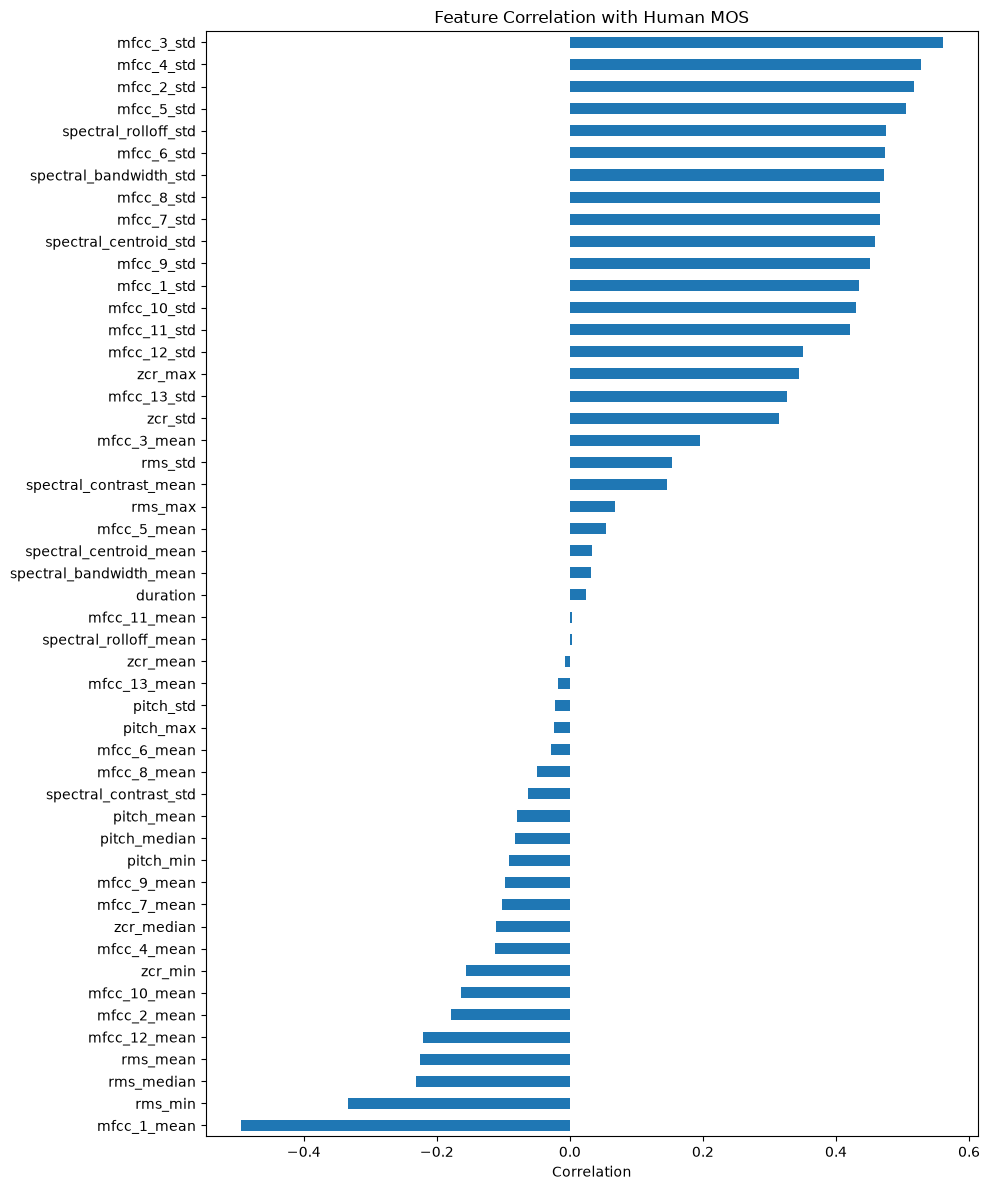

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 12))

correlation.sort_values().plot(
    kind="barh"
)

plt.title(
    "Feature Correlation with Human MOS"
)

plt.xlabel("Correlation")

plt.tight_layout()
plt.show()

In [27]:
import os

os.makedirs(
    "../data/processed",
    exist_ok=True
)

In [29]:
feature_df.to_csv(
    "../data/processed/voiceiq_features_1000.csv",
    index=False
)